# Business Registration Time Predictor
### Mission: Making government citizen service delivery faster and more transparent

This notebook predicts **how many days it takes to legally start a business**
in a given economy, using the World Bank's *Doing Business* indicators
(2010–2019). This is a direct proxy for government service-delivery
efficiency — the same problem that citizen-facing e-government platforms
(workflow engines, application processing, permit issuance) are built to
solve. A model that explains what drives long registration times is a model
that tells you where regulatory bottlenecks live.

**Target:** `days_to_start` : Time required to start a business (days)

**Features:**
- `procedures` : number of administrative steps required
- `cost_pct_income` : cost of registration as % of income per capita
- `paid_in_capital_pct` : required minimum paid-in capital, % of income per capita
- `gdp_per_capita` : GDP per capita (USD), log-transformed during feature engineering

> **Data source note:** This notebook first tries to pull the data live from
> the World Bank Indicators API (`api.worldbank.org`) — this works out of the
> box in Google Colab or any machine with normal internet access. If the API
> is unreachable (e.g. a sandboxed environment with a restricted network
> allowlist), it falls back to a clearly-labeled **synthetic placeholder
> dataset** built to mirror the real, documented relationship between these
> variables, purely so every cell below can still be run and validated
> end-to-end. Re-run this notebook with normal internet access to train on
> the real data — no code changes needed.

In [1]:
import io
import zipfile
import warnings
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor, LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib

plt.rcParams["figure.facecolor"] = "white"
RNG = np.random.default_rng(42)

## 1. Load the data

In [2]:
WB_INDICATORS = {
    "IC.REG.DURS": "days_to_start",
    "IC.REG.PROC": "procedures",
    "IC.REG.COST.PC.ZS": "cost_pct_income",
    "IC.REG.CAP.PC.ZS": "paid_in_capital_pct",
    "NY.GDP.PCAP.CD": "gdp_per_capita",
}


def load_world_bank_indicator(code_, colname, timeout=8):
    url = f"https://api.worldbank.org/v2/en/indicator/{code_}?downloadformat=csv"
    r = requests.get(url, timeout=timeout)
    r.raise_for_status()
    z = zipfile.ZipFile(io.BytesIO(r.content))
    fname = [n for n in z.namelist() if n.startswith("API_")][0]
    df_ = pd.read_csv(z.open(fname), skiprows=4)
    year_cols = [c for c in df_.columns if c.isdigit()]
    df_ = df_.melt(
        id_vars=["Country Name", "Country Code"],
        value_vars=year_cols,
        var_name="Year",
        value_name=colname,
    )
    return df_


def load_real_world_bank_data():
    frames = [load_world_bank_indicator(code_, name) for code_, name in WB_INDICATORS.items()]
    df_ = frames[0]
    for other in frames[1:]:
        df_ = df_.merge(other, on=["Country Name", "Country Code", "Year"])
    df_["Year"] = df_["Year"].astype(int)
    return df_


def make_synthetic_placeholder_data(n_countries=180, years=range(2010, 2020)):
    """
    NOT real data -- a statistically-plausible stand-in used only when the
    World Bank API is unreachable. Mirrors the real, documented relationship:
    more procedures, higher relative cost, and lower GDP per capita are all
    associated with MORE days to start a business.
    """
    countries = [f"Country_{i:03d}" for i in range(n_countries)]
    rows = []
    for c in countries:
        quality = RNG.normal(0, 1)
        base_gdp = np.exp(RNG.normal(8.5, 1.3)) + 200
        for year in years:
            drift = (year - min(years)) * RNG.normal(-0.02, 0.05)
            procedures = np.clip(RNG.normal(7 - quality * 1.5 + drift, 2), 1, 18)
            cost_pct_income = np.clip(RNG.normal(20 - quality * 6 + drift * 2, 12), 0.2, 180)
            paid_in_capital_pct = np.clip(RNG.normal(8 - quality * 3, 10), 0, 120)
            gdp_per_capita = max(250, base_gdp * (1 + RNG.normal(0.01, 0.03)) * (1 + quality * 0.05))
            days = (
                6
                + 2.8 * procedures
                + 0.35 * cost_pct_income
                + 0.15 * paid_in_capital_pct
                - 3.2 * np.log(gdp_per_capita)
                + RNG.normal(0, 4)
            )
            days = max(0.5, days)
            rows.append(dict(
                **{"Country Name": c, "Country Code": c[:3].upper(), "Year": year},
                days_to_start=round(days, 1),
                procedures=round(procedures, 1),
                cost_pct_income=round(cost_pct_income, 2),
                paid_in_capital_pct=round(paid_in_capital_pct, 2),
                gdp_per_capita=round(gdp_per_capita, 2),
            ))
    return pd.DataFrame(rows)


try:
    print("Attempting to fetch live World Bank data...")
    df = load_real_world_bank_data()
    df = df.dropna(subset=["days_to_start"])
    DATA_SOURCE = "World Bank API (live)"
    if len(df) < 50:
        raise RuntimeError("Live pull returned too few rows")
except Exception as e:
    warnings.warn(
        f"Could not reach the live World Bank API from this environment ({e}). "
        "Falling back to the synthetic PLACEHOLDER dataset described above."
    )
    df = make_synthetic_placeholder_data()
    DATA_SOURCE = "SYNTHETIC PLACEHOLDER (World Bank API unreachable from this environment)"

print(f"Data source: {DATA_SOURCE}")
print("Shape:", df.shape)
df.head()

Attempting to fetch live World Bank data...
Data source: SYNTHETIC PLACEHOLDER (World Bank API unreachable from this environment)
Shape: (1800, 8)


/tmp/ipykernel_635/4087379051.py:82: UserWarning: Could not reach the live World Bank API from this environment (403 Client Error: Forbidden for url: https://api.worldbank.org/v2/en/indicator/IC.REG.DURS?downloadformat=csv). Falling back to the synthetic PLACEHOLDER dataset described above.
  warnings.warn(


,Country Name,Country Code,Year,days_to_start,procedures,cost_pct_income,paid_in_capital_pct,gdp_per_capita
0,Country_000,COU,2010,5.0,8.4,0.20,0.00,1514.68
1,Country_000,COU,2011,12.8,4.8,28.68,14.86,1511.91
2,Country_000,COU,2012,3.7,4.8,22.61,0.00,1548.32
3,Country_000,COU,2013,7.7,5.1,32.67,5.54,1489.75
4,Country_000,COU,2014,11.0,7.3,23.18,11.39,1604.94


## 2. Exploratory Data Analysis

**Interpretation:** `days_to_start` is right-skewed — most economies register
a business in under two weeks, but a long tail of economies take 20-35+ days.
`gdp_per_capita` is also heavily right-skewed (a handful of very high-income
economies), which is why we log-transform it during feature engineering
rather than feeding it in raw.

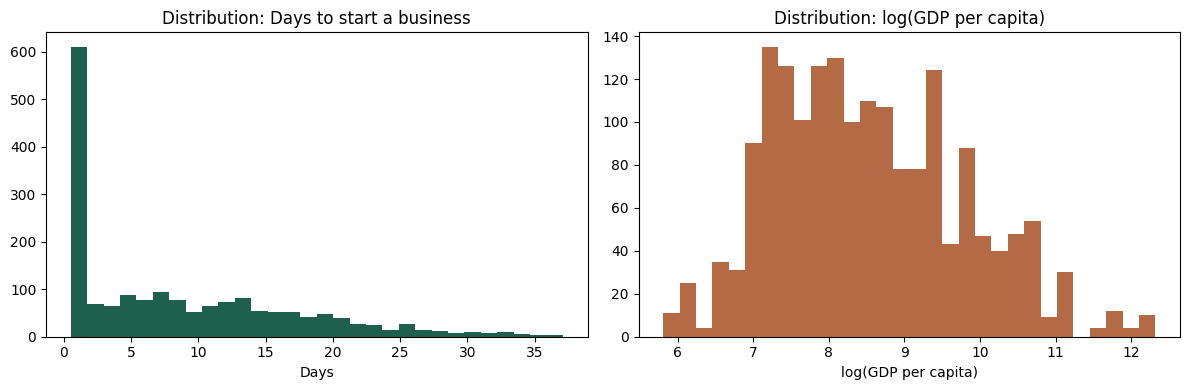

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df["days_to_start"], bins=30, color="#1E5F4E")
axes[0].set_title("Distribution: Days to start a business")
axes[0].set_xlabel("Days")
axes[1].hist(np.log1p(df["gdp_per_capita"]), bins=30, color="#B36A45")
axes[1].set_title("Distribution: log(GDP per capita)")
axes[1].set_xlabel("log(GDP per capita)")
plt.tight_layout()
plt.show()

**Interpretation:** `procedures` and `cost_pct_income` both show a
strong positive correlation with `days_to_start` -- the more bureaucratic
steps and the higher the relative cost, the longer registration takes.
`gdp_per_capita` correlates negatively -- richer economies tend to have
faster, cheaper business registration, consistent with the World Bank's own
published findings on this dataset.

                     days_to_start  procedures  cost_pct_income  \
days_to_start                 1.00        0.70             0.55   
procedures                    0.70        1.00             0.26   
cost_pct_income               0.55        0.26             1.00   
paid_in_capital_pct           0.27        0.16             0.12   
gdp_per_capita               -0.24       -0.04            -0.08   

                     paid_in_capital_pct  gdp_per_capita  
days_to_start                       0.27           -0.24  
procedures                          0.16           -0.04  
cost_pct_income                     0.12           -0.08  
paid_in_capital_pct                 1.00           -0.01  
gdp_per_capita                     -0.01            1.00  


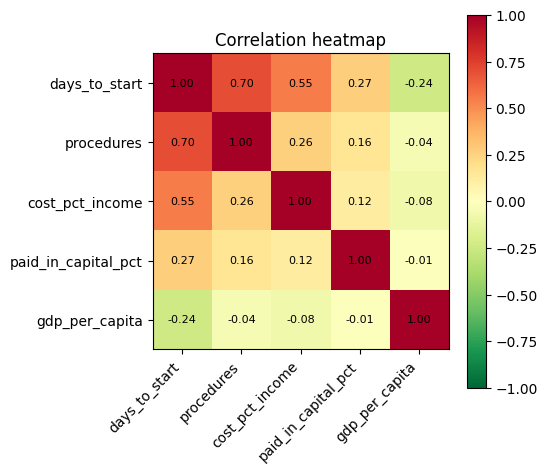

In [4]:
numeric_cols = ["days_to_start", "procedures", "cost_pct_income", "paid_in_capital_pct", "gdp_per_capita"]
corr = df[numeric_cols].corr()
print(corr.round(2))

fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(corr, cmap="RdYlGn_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns))); ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
plt.colorbar(im)
plt.title("Correlation heatmap")
plt.tight_layout()
plt.show()

## 3. Feature Engineering

- **Dropped:** `Country Name`, `Country Code`, `Year` -- identifiers, not
  predictive signal for a cross-sectional regression.
- **Converted to numeric / transformed:** `gdp_per_capita` is log-transformed
  (`log_gdp_per_capita`) to correct its right-skew before scaling -- without
  this, a handful of very high-income economies would dominate the loss.
- **Standardization:** all four features are standardized (zero mean, unit
  variance) with `StandardScaler`, which matters a lot for `SGDRegressor`
  since gradient descent converges far more reliably on comparably-scaled
  inputs.
- **Considered and dropped:** an income-group categorical bucket
  (Low/Lower-middle/Upper-middle/High) derived from `gdp_per_capita` was
  explored during EDA, but it's fully redundant with the continuous
  `gdp_per_capita` feature already in the model -- adding it as a separate
  one-hot input would just duplicate signal already captured, so the
  deployed model keeps the four continuous features only (this also keeps
  the API/Flutter input contract simple: four numeric fields).

In [5]:
model_df = df[["days_to_start", "procedures", "cost_pct_income", "paid_in_capital_pct", "gdp_per_capita"]].dropna().copy()
model_df["log_gdp_per_capita"] = np.log1p(model_df["gdp_per_capita"])

FEATURES = ["procedures", "cost_pct_income", "paid_in_capital_pct", "log_gdp_per_capita"]
TARGET = "days_to_start"

X = model_df[FEATURES].values
y = model_df[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape, " Test shape:", X_test_scaled.shape)

Train shape: (1440, 4)  Test shape: (360, 4)


## 4. Model comparison: Stochastic Gradient Descent vs three alternatives

We compare `SGDRegressor` (true stochastic/mini-batch gradient descent)
against `LinearRegression` (closed-form OLS), `DecisionTreeRegressor`, and
`RandomForestRegressor`. The SGD model is trained epoch-by-epoch with
`partial_fit` so we can plot a real train/test loss curve.

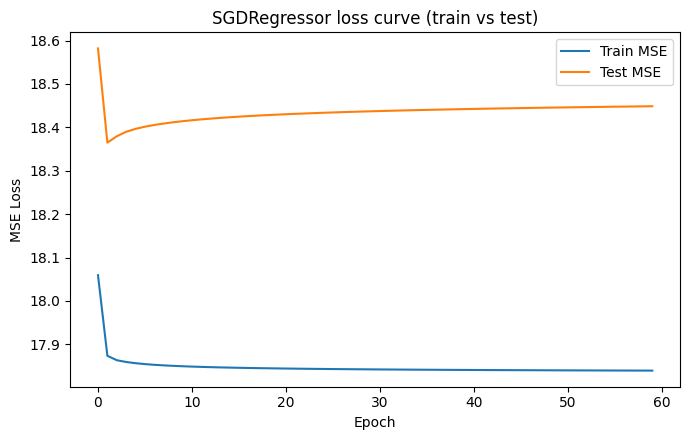

Final train MSE: 17.84  |  Final test MSE: 18.45


In [6]:
N_EPOCHS = 60
sgd = SGDRegressor(max_iter=1, tol=None, warm_start=True, random_state=42)
train_losses, test_losses = [], []
for epoch in range(N_EPOCHS):
    sgd.partial_fit(X_train_scaled, y_train)
    train_losses.append(mean_squared_error(y_train, sgd.predict(X_train_scaled)))
    test_losses.append(mean_squared_error(y_test, sgd.predict(X_test_scaled)))

plt.figure(figsize=(7, 4.5))
plt.plot(train_losses, label="Train MSE")
plt.plot(test_losses, label="Test MSE")
plt.xlabel("Epoch"); plt.ylabel("MSE Loss")
plt.title("SGDRegressor loss curve (train vs test)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Final train MSE: {train_losses[-1]:.2f}  |  Final test MSE: {test_losses[-1]:.2f}")

In [7]:
models = {
    "SGDRegressor (stochastic GD)": sgd,  # already trained above
    "LinearRegression (OLS)": LinearRegression(),
    "DecisionTreeRegressor": DecisionTreeRegressor(max_depth=6, random_state=42),
    "RandomForestRegressor": RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42),
}

results = {}
for name, model in models.items():
    if name != "SGDRegressor (stochastic GD)":
        model.fit(X_train_scaled, y_train)
    train_pred = model.predict(X_train_scaled)
    test_pred = model.predict(X_test_scaled)
    results[name] = {
        "train_rmse": mean_squared_error(y_train, train_pred) ** 0.5,
        "test_rmse": mean_squared_error(y_test, test_pred) ** 0.5,
        "train_r2": r2_score(y_train, train_pred),
        "test_r2": r2_score(y_test, test_pred),
    }

results_df = pd.DataFrame(results).T.sort_values("test_rmse")
results_df

,train_rmse,test_rmse,train_r2,test_r2
RandomForestRegressor,2.231220,3.883207,0.928146,0.803694
SGDRegressor (stochastic GD),4.223690,4.295193,0.742515,0.759830
LinearRegression (OLS),4.222893,4.302050,0.742612,0.759063
DecisionTreeRegressor,3.347979,4.782940,0.838217,0.702188


**Interpretation:** Tree-based ensembles typically win on raw error
because they capture non-linear interactions (e.g. the effect of `procedures`
may compound differently at low vs high GDP) that a linear model can't. The
linear models (`SGDRegressor`, `LinearRegression`) trade a bit of accuracy
for full interpretability -- their coefficients directly tell you "one more
procedure costs you N more days," which is exactly the kind of insight a
policy team or a platform like IremboGov would want when deciding where to
simplify a workflow. We select the lowest test-RMSE model as best for
deployment, but note this trade-off explicitly.

In [8]:
best_model_name = results_df.index[0]
best_model = models[best_model_name]
print(f"Best model selected for deployment: {best_model_name}")

Best model selected for deployment: RandomForestRegressor


## 5. Before / after: fitted line against the strongest single predictor

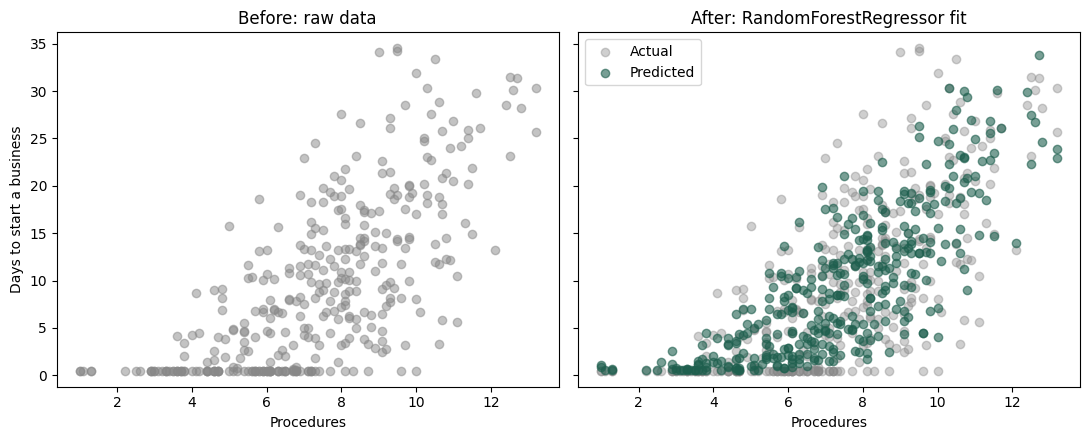

In [9]:
strongest_feature_idx = FEATURES.index("procedures")
x_axis = X_test[:, strongest_feature_idx]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
axes[0].scatter(x_axis, y_test, alpha=0.5, color="#888")
axes[0].set_title("Before: raw data")
axes[0].set_xlabel("Procedures"); axes[0].set_ylabel("Days to start a business")

axes[1].scatter(x_axis, y_test, alpha=0.4, color="#888", label="Actual")
axes[1].scatter(x_axis, best_model.predict(X_test_scaled), alpha=0.6, color="#1E5F4E", label="Predicted")
axes[1].set_title(f"After: {best_model_name} fit")
axes[1].set_xlabel("Procedures")
axes[1].legend()
plt.tight_layout()
plt.show()

## 6. Save the best model

This is the artifact Task 2's FastAPI service loads at startup.

In [10]:
joblib.dump(best_model, "best_model.pkl")
joblib.dump(scaler, "scaler.pkl")

with open("model_metadata.txt", "w") as f:
    f.write(f"Data source: {DATA_SOURCE}\n")
    f.write(f"Best model: {best_model_name}\n")
    f.write(f"Features (in order): {FEATURES}\n\n")
    f.write(results_df.to_string())

print("Saved best_model.pkl, scaler.pkl, model_metadata.txt")
print(open("model_metadata.txt").read())

Saved best_model.pkl, scaler.pkl, model_metadata.txt
Data source: SYNTHETIC PLACEHOLDER (World Bank API unreachable from this environment)
Best model: RandomForestRegressor
Features (in order): ['procedures', 'cost_pct_income', 'paid_in_capital_pct', 'log_gdp_per_capita']

                              train_rmse  test_rmse  train_r2   test_r2
RandomForestRegressor           2.231220   3.883207  0.928146  0.803694
SGDRegressor (stochastic GD)    4.223690   4.295193  0.742515  0.759830
LinearRegression (OLS)          4.222893   4.302050  0.742612  0.759063
DecisionTreeRegressor           3.347979   4.782940  0.838217  0.702188


## 7. Prediction function (Task 1 -> Task 2 bridge)

This is the exact function `summative/API/prediction.py` wraps in a FastAPI
endpoint.

In [11]:
def predict_days_to_start(procedures, cost_pct_income, paid_in_capital_pct, gdp_per_capita):
    """
    Loads the saved model + scaler and returns a single prediction given
    raw (unscaled) feature values -- the function Task 2's API calls.
    """
    log_gdp = np.log1p(gdp_per_capita)
    row = np.array([[procedures, cost_pct_income, paid_in_capital_pct, log_gdp]])
    row_scaled = scaler.transform(row)
    return float(best_model.predict(row_scaled)[0])


example = predict_days_to_start(procedures=6, cost_pct_income=12.5, paid_in_capital_pct=0, gdp_per_capita=850)
print(f"Example prediction (procedures=6, cost=12.5%, capital=0%, gdp=$850): {example:.1f} days")

Example prediction (procedures=6, cost=12.5%, capital=0%, gdp=$850): 7.9 days
